In [1]:
from pathlib import Path
import gc
import json

import numpy as np
import pandas as pd
import h5py
import soundfile as sf
import matplotlib.pyplot as plt

from scipy.signal import spectrogram
from scipy.ndimage import binary_closing
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tqdm.auto import tqdm

# 1. Setup

In [2]:
BASE_DIR = Path.cwd() / "yang_long_2025_budgie_aac"
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = BASE_DIR / "processed"
OUT_DIR = BASE_DIR / "model_ready_all_parrots"

OUT_DIR.mkdir(parents=True, exist_ok=True)

BIRDS = [
    "Bl122_ChronicLeftAAC",
    "Li145_ChronicLeftAAC",
    "Or61_ChronicLeftAAC",
    "Ti81_ChronicLeftAAC",
]

OUT_H5 = OUT_DIR / "all_parrots_audioX_spikesY.h5"
EVENTS_CSV = OUT_DIR / "all_parrots_vocal_events.csv"

# Use 300 sec first. Set None for full data.
MAX_DURATION_SEC = 300

FS = 30000

# Spectrogram settings
STFT_WINDOW_SEC = 0.0085
STFT_STEP_SEC = 0.001
NFFT = 1024
FREQ_MIN_HZ = 300
FREQ_MAX_HZ = 7000

# Alignment
SPIKE_BIN_SEC = STFT_STEP_SEC
MOTOR_DELAY_SEC = 0.012

# Vocal event detection
EVENT_Z_THRESHOLD = 4.0
EVENT_MIN_PIXELS = 50
EVENT_ANALYSIS_MS = 3
MIN_EVENT_MS = 2
CLOSE_GAP_MS = 2

# t-SNE
FIXED_EVENT_MS = 300
N_PCA = 25
TSNE_PERPLEXITY = 30
MAX_EVENTS_FOR_TSNE = 2000

OVERWRITE = True

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/model_ready_all_parrots


# 2. build aligned data
X = audio spectrogram\
Y = spikes

In [3]:
def get_paths(bird):
    return {
        "audio": DATA_DIR / bird / "audioCh3_HP.flac",
        "spikes": PROCESSED_DIR / bird / "spikes.h5",
    }


def load_spike_list(spikes_h5):
    spike_list = []
    with h5py.File(spikes_h5, "r") as h5:
        spike_times = h5["spike_times_sec"]
        ptr = h5["unit_ptr"][:]
        for u in range(len(ptr) - 1):
            spike_list.append(spike_times[ptr[u]:ptr[u + 1]])
    return spike_list


def read_audio(audio_path, max_duration_sec):
    info = sf.info(str(audio_path))
    assert info.samplerate == FS

    stop = info.frames if max_duration_sec is None else min(info.frames, int(max_duration_sec * FS))
    audio, fs = sf.read(str(audio_path), start=0, stop=stop, always_2d=False)

    if audio.ndim > 1:
        audio = audio[:, 0]

    return audio.astype(np.float32), fs


def make_spectrogram(audio, fs):
    nperseg = int(round(STFT_WINDOW_SEC * fs))
    hop = int(round(STFT_STEP_SEC * fs))
    noverlap = nperseg - hop

    freq, time, power = spectrogram(
        audio,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=NFFT,
        detrend=False,
        scaling="spectrum",
        mode="psd",
    )

    S_db = 10 * np.log10(power + 1e-12)
    keep = (freq >= FREQ_MIN_HZ) & (freq <= FREQ_MAX_HZ)

    return S_db[keep].T.astype(np.float32), time.astype(np.float64), freq[keep].astype(np.float32)


def bin_spikes_on_audio_grid(spike_list, audio_time):
    neural_time = audio_time - MOTOR_DELAY_SEC
    half = SPIKE_BIN_SEC / 2

    valid = neural_time - half >= 0
    audio_time_valid = audio_time[valid]
    neural_time_valid = neural_time[valid]

    edges = np.concatenate([neural_time_valid - half, [neural_time_valid[-1] + half]])
    Y = np.zeros((len(neural_time_valid), len(spike_list)), dtype=np.uint16)

    for u, st in enumerate(spike_list):
        left = np.searchsorted(st, edges[0], side="left")
        right = np.searchsorted(st, edges[-1], side="right")
        Y[:, u] = np.histogram(st[left:right], bins=edges)[0]

    return Y, audio_time_valid, valid


if OUT_H5.exists() and OVERWRITE:
    OUT_H5.unlink()

with h5py.File(OUT_H5, "w") as h5:
    h5.attrs["meaning"] = "X_audio[t] = spectrogram at audio time t; Y_spikes[t] = spike counts at t - 12 ms"
    h5.attrs["stft_window_sec"] = STFT_WINDOW_SEC
    h5.attrs["stft_step_sec"] = STFT_STEP_SEC
    h5.attrs["spike_bin_sec"] = SPIKE_BIN_SEC
    h5.attrs["motor_delay_sec"] = MOTOR_DELAY_SEC
    h5.attrs["max_duration_sec"] = -1 if MAX_DURATION_SEC is None else MAX_DURATION_SEC

    for bird_id, bird in enumerate(BIRDS):
        print("\n" + "=" * 80)
        print(bird)

        paths = get_paths(bird)

        audio, fs = read_audio(paths["audio"], MAX_DURATION_SEC)
        X_audio, audio_time, freq_hz = make_spectrogram(audio, fs)

        spike_list = load_spike_list(paths["spikes"])
        Y_spikes, audio_time_valid, valid = bin_spikes_on_audio_grid(spike_list, audio_time)
        X_audio = X_audio[valid]

        grp = h5.create_group(bird)
        grp.attrs["bird_id"] = bird_id
        grp.attrs["n_units"] = Y_spikes.shape[1]

        grp.create_dataset("X_audio", data=X_audio, compression="lzf")
        grp.create_dataset("Y_spikes", data=Y_spikes, compression="lzf")
        grp.create_dataset("time_audio_sec", data=audio_time_valid, compression="lzf")
        grp.create_dataset("freq_hz", data=freq_hz)

        print("X_audio:", X_audio.shape)
        print("Y_spikes:", Y_spikes.shape)

        del audio, X_audio, Y_spikes, audio_time, audio_time_valid, spike_list
        gc.collect()

print("Saved:", OUT_H5)


Bl122_ChronicLeftAAC
X_audio: (299983, 228)
Y_spikes: (299983, 43)

Li145_ChronicLeftAAC
X_audio: (299983, 228)
Y_spikes: (299983, 81)

Or61_ChronicLeftAAC
X_audio: (299983, 228)
Y_spikes: (299983, 47)

Ti81_ChronicLeftAAC
X_audio: (299983, 228)
Y_spikes: (299983, 49)
Saved: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/model_ready_all_parrots/all_parrots_audioX_spikesY.h5


# 3. read as numpy

In [4]:
def load_all_numpy():
    data = {}
    with h5py.File(OUT_H5, "r") as h5:
        for bird in BIRDS:
            data[bird] = {
                "X_audio": h5[bird]["X_audio"][:],
                "Y_spikes": h5[bird]["Y_spikes"][:],
                "time": h5[bird]["time_audio_sec"][:],
                "freq": h5[bird]["freq_hz"][:],
            }
    return data


data = load_all_numpy()

for bird in BIRDS:
    print("\n", bird)
    print("X_audio:", data[bird]["X_audio"].shape, data[bird]["X_audio"].dtype)
    print("Y_spikes:", data[bird]["Y_spikes"].shape, data[bird]["Y_spikes"].dtype)


 Bl122_ChronicLeftAAC
X_audio: (299983, 228) float32
Y_spikes: (299983, 43) uint16

 Li145_ChronicLeftAAC
X_audio: (299983, 228) float32
Y_spikes: (299983, 81) uint16

 Or61_ChronicLeftAAC
X_audio: (299983, 228) float32
Y_spikes: (299983, 47) uint16

 Ti81_ChronicLeftAAC
X_audio: (299983, 228) float32
Y_spikes: (299983, 49) uint16


In [5]:
bird = "Li145_ChronicLeftAAC"

X_audio = data[bird]["X_audio"]
Y_spikes = data[bird]["Y_spikes"]
time = data[bird]["time"]
freq = data[bird]["freq"]

print("bird:", bird)
print("X_audio:", X_audio.shape)
print("Y_spikes:", Y_spikes.shape)
print("time:", time.shape)
print("freq:", freq.shape)

bird: Li145_ChronicLeftAAC
X_audio: (299983, 228)
Y_spikes: (299983, 81)
time: (299983,)
freq: (228,)


# 4. Visualization
## 4.1 Fig 1: spectrogram + aligned spikes

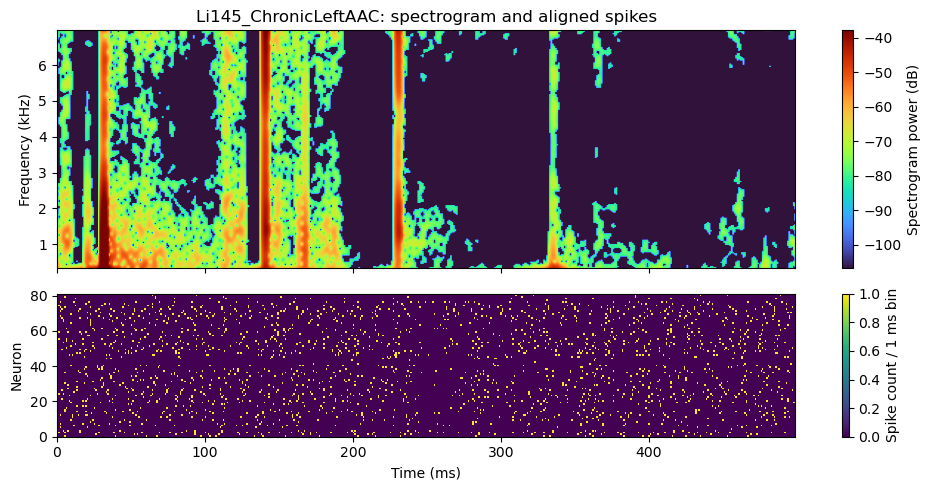

In [6]:
def display_spectrogram(S):
    S = S.copy()
    vmin, vmax = np.percentile(S, [5, 99.7])
    S = np.clip(S, vmin, vmax)
    bg = vmin + 0.35 * (vmax - vmin)
    S[S < bg] = vmin
    return S, vmin, vmax


def find_representative_window(bird, duration_sec=0.5):
    X = data[bird]["X_audio"]
    time = data[bird]["time"]

    win = int(round(duration_sec / STFT_STEP_SEC))
    score = np.percentile(X, 95, axis=1)

    best = 0
    best_score = -np.inf
    for i in range(0, len(score) - win, win):
        s = score[i:i + win].max()
        if s > best_score:
            best_score = s
            best = i

    return best, best + win


def plot_representative_period(bird="Li145_ChronicLeftAAC", duration_sec=0.5):
    i0, i1 = find_representative_window(bird, duration_sec)

    X = data[bird]["X_audio"][i0:i1]
    Y = data[bird]["Y_spikes"][i0:i1]
    t = data[bird]["time"][i0:i1]
    f = data[bird]["freq"]

    X_show, vmin, vmax = display_spectrogram(X)
    t_ms = (t - t[0]) * 1000

    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2]},
    )

    im0 = axes[0].imshow(
        X_show.T,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        extent=[t_ms[0], t_ms[-1], f[0] / 1000, f[-1] / 1000],
    )
    axes[0].set_ylabel("Frequency (kHz)")
    axes[0].set_title(f"{bird}: spectrogram and aligned spikes")
    fig.colorbar(im0, ax=axes[0], label="Spectrogram power (dB)")

    im1 = axes[1].imshow(
        Y.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[t_ms[0], t_ms[-1], 0, Y.shape[1]],
    )
    axes[1].set_ylabel("Neuron")
    axes[1].set_xlabel("Time (ms)")
    fig.colorbar(im1, ax=axes[1], label="Spike count / 1 ms bin")

    plt.tight_layout()
    plt.show()


plot_representative_period("Li145_ChronicLeftAAC", duration_sec=0.5)

## 4.2 Fig 2: vocal event t-SNE

In [7]:
def robust_zscore_spectrogram(S):
    med = np.median(S, axis=0, keepdims=True)
    mad = np.median(np.abs(S - med), axis=0, keepdims=True)
    return (S - med) / (1.4826 * mad + 1e-6)


def mask_to_events(mask, time):
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    events = []
    s = idx[0]
    prev = idx[0]

    for x in idx[1:]:
        if x == prev + 1:
            prev = x
        else:
            if (prev + 1 - s) * STFT_STEP_SEC * 1000 >= MIN_EVENT_MS:
                events.append((s, prev + 1))
            s = x
            prev = x

    if (prev + 1 - s) * STFT_STEP_SEC * 1000 >= MIN_EVENT_MS:
        events.append((s, prev + 1))

    return events


def label_call_warble(events, time):
    labels = ["call"] * len(events)
    if len(events) < 3:
        return labels

    gaps = []
    for i in range(len(events) - 1):
        _, e0 = events[i]
        s1, _ = events[i + 1]
        gaps.append(time[s1] - time[e0 - 1])

    start = 0
    while start < len(events):
        end = start
        while end < len(events) - 1 and gaps[end] < 1.0:
            end += 1

        if end - start + 1 >= 3:
            for k in range(start, end + 1):
                labels[k] = "warble_syllable"

        start = end + 1

    return labels


def detect_events(S, time):
    Z = robust_zscore_spectrogram(S)
    B = Z > EVENT_Z_THRESHOLD

    close_frames = max(1, int(round(CLOSE_GAP_MS / 1000 / STFT_STEP_SEC)))
    B = binary_closing(B, structure=np.ones((close_frames, 1))).astype(bool)

    win = max(1, int(round(EVENT_ANALYSIS_MS / 1000 / STFT_STEP_SEC)))
    pixel_count = np.convolve(B.sum(axis=1), np.ones(win, dtype=int), mode="same")

    vocal_mask = pixel_count >= EVENT_MIN_PIXELS
    events = mask_to_events(vocal_mask, time)
    labels = label_call_warble(events, time)

    return events, labels, pixel_count


all_rows = []

for bird in BIRDS:
    S = data[bird]["X_audio"]
    time = data[bird]["time"]

    events, labels, score = detect_events(S, time)

    for event_id, ((s, e), label) in enumerate(zip(events, labels)):
        all_rows.append({
            "bird": bird,
            "event_id": event_id,
            "start_idx": s,
            "end_idx": e,
            "start_sec": float(time[s]),
            "end_sec": float(time[e - 1] + STFT_STEP_SEC),
            "duration_ms": float((e - s) * STFT_STEP_SEC * 1000),
            "label": label,
            "score": float(score[s:e].max()),
        })

events_df = pd.DataFrame(all_rows)
events_df.to_csv(EVENTS_CSV, index=False)

display(events_df.groupby(["bird", "label"]).size().reset_index(name="n"))

,bird,label,n
0,Bl122_ChronicLeftAAC,call,14
1,Bl122_ChronicLeftAAC,warble_syllable,2196
2,Li145_ChronicLeftAAC,call,25
3,Li145_ChronicLeftAAC,warble_syllable,1521
4,Or61_ChronicLeftAAC,call,40
5,Or61_ChronicLeftAAC,warble_syllable,682
6,Ti81_ChronicLeftAAC,call,49
7,Ti81_ChronicLeftAAC,warble_syllable,144


In [8]:
def event_to_fixed_vector(S_event, fixed_len=300):
    lo = np.percentile(S_event, 1)
    hi = np.percentile(S_event, 99.7)

    S = (S_event - lo) / (hi - lo + 1e-8)
    S = np.clip(S, 0, 1)
    S[S < 0.60] = 0.0

    out = np.zeros((fixed_len, S.shape[1]), dtype=np.float32)
    L = min(fixed_len, S.shape[0])
    out[:L] = S[:L]

    return out.ravel()


def make_tsne_for_bird(bird="Li145_ChronicLeftAAC"):
    df = events_df[events_df["bird"] == bird].copy()
    df = df.sort_values("start_sec").reset_index(drop=True)

    if len(df) > MAX_EVENTS_FOR_TSNE:
        df = df.sample(MAX_EVENTS_FOR_TSNE, random_state=0).reset_index(drop=True)

    fixed_len = int(FIXED_EVENT_MS / 1000 / STFT_STEP_SEC)

    vectors = []
    labels = []

    S_all = data[bird]["X_audio"]

    for _, row in tqdm(df.iterrows(), total=len(df)):
        s = int(row["start_idx"])
        e = int(row["end_idx"])
        vectors.append(event_to_fixed_vector(S_all[s:e], fixed_len=fixed_len))
        labels.append(row["label"])

    X = np.vstack(vectors)
    labels = np.array(labels)

    X = X - X.mean(axis=0, keepdims=True)

    pca = PCA(n_components=min(N_PCA, X.shape[0] - 1), random_state=0)
    Z = pca.fit_transform(X)

    perp = min(TSNE_PERPLEXITY, max(5, (len(Z) - 1) // 3))

    U = TSNE(
        n_components=2,
        perplexity=perp,
        init="pca",
        learning_rate="auto",
        random_state=0,
    ).fit_transform(Z)

    tsne_df = pd.DataFrame({
        "tsne1": U[:, 0],
        "tsne2": U[:, 1],
        "label": labels,
        "duration_ms": df["duration_ms"].to_numpy(),
    })

    return tsne_df, Z, df


BIRD_FOR_TSNE = "Li145_ChronicLeftAAC"
tsne_df, Z, event_meta = make_tsne_for_bird(BIRD_FOR_TSNE)

display(tsne_df["label"].value_counts())

  0%|          | 0/1546 [00:00<?, ?it/s]

label
warble_syllable    1521
call                 25
Name: count, dtype: int64

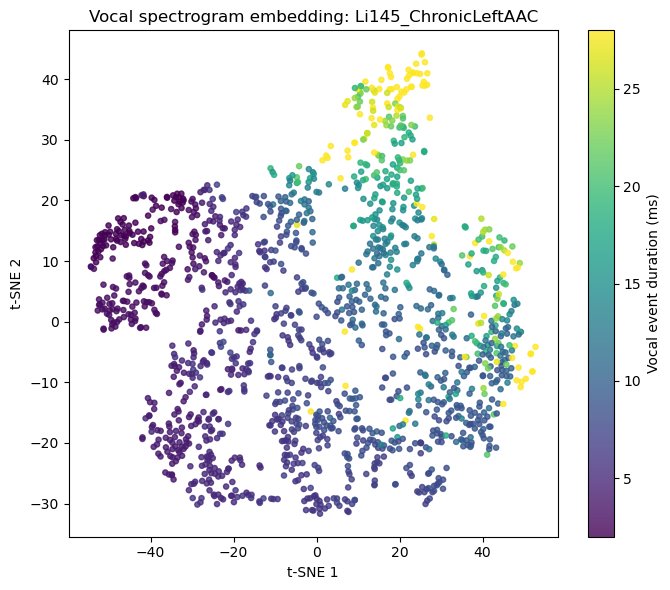

In [15]:
plt.figure(figsize=(7, 6))

duration = tsne_df["duration_ms"].to_numpy()

# Clip color scale so a few very long events do not dominate the colorbar.
vmin, vmax = np.percentile(duration, [5, 95])

sc = plt.scatter(
    tsne_df["tsne1"],
    tsne_df["tsne2"],
    c=duration,
    s=14,
    alpha=0.8,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"Vocal spectrogram embedding: {BIRD_FOR_TSNE}")

cbar = plt.colorbar(sc)
cbar.set_label("Vocal event duration (ms)")

plt.tight_layout()
plt.show()

In [10]:
def get_model_data(bird):
    return {
        "X_audio": data[bird]["X_audio"],
        "Y_spikes": data[bird]["Y_spikes"],
        "time": data[bird]["time"],
        "freq": data[bird]["freq"],
    }


bird = "Li145_ChronicLeftAAC"
model_data = get_model_data(bird)

X = model_data["X_audio"]
Y = model_data["Y_spikes"]

print("bird:", bird)
print("X = audio spectrogram:", X.shape, X.dtype)
print("Y = aligned spike counts:", Y.shape, Y.dtype)
print("time:", model_data["time"].shape)
print("freq:", model_data["freq"].shape)

print("\nMeaning:")
print("X[t, :] = spectrogram at audio time t")
print("Y[t, :] = spike counts around audio time t - 12 ms")

bird: Li145_ChronicLeftAAC
X = audio spectrogram: (299983, 228) float32
Y = aligned spike counts: (299983, 81) uint16
time: (299983,)
freq: (228,)

Meaning:
X[t, :] = spectrogram at audio time t
Y[t, :] = spike counts around audio time t - 12 ms


In [12]:
model_data['X_audio']

array([[ -99.64859 , -100.06082 , -100.653984, ..., -114.54512 ,
        -107.60193 , -100.64444 ],
       [-100.62396 , -102.11702 , -104.195404, ..., -104.59769 ,
        -101.63809 ,  -98.52695 ],
       [-102.574646, -106.32888 , -112.72345 , ...,  -96.27922 ,
         -94.74289 ,  -93.92763 ],
       ...,
       [ -91.02524 ,  -92.46963 ,  -94.218475, ...,  -99.02337 ,
         -98.313065,  -98.04192 ],
       [ -94.38451 ,  -97.697716, -100.37233 , ...,  -99.49848 ,
         -98.859314,  -98.517746],
       [ -94.073715,  -98.058846, -102.89708 , ..., -101.054306,
        -101.16742 , -101.36379 ]], dtype=float32)

In [13]:
model_data["Y_spikes"]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [14]:
model_data

{'X_audio': array([[ -99.64859 , -100.06082 , -100.653984, ..., -114.54512 ,
         -107.60193 , -100.64444 ],
        [-100.62396 , -102.11702 , -104.195404, ..., -104.59769 ,
         -101.63809 ,  -98.52695 ],
        [-102.574646, -106.32888 , -112.72345 , ...,  -96.27922 ,
          -94.74289 ,  -93.92763 ],
        ...,
        [ -91.02524 ,  -92.46963 ,  -94.218475, ...,  -99.02337 ,
          -98.313065,  -98.04192 ],
        [ -94.38451 ,  -97.697716, -100.37233 , ...,  -99.49848 ,
          -98.859314,  -98.517746],
        [ -94.073715,  -98.058846, -102.89708 , ..., -101.054306,
         -101.16742 , -101.36379 ]], dtype=float32),
 'Y_spikes': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 'time': array([1.3250000e-02, 1.4250000e-02, 1.5250000e-02, ..., 2.9999325e+02,
        2.9999425e+02, 2.99